# Where does Leela know a pin *matters*?

The `sf-probe` layer sweep, run on a Leela transformer (`t1-256x10-distilled`): one
MLP probe per tap of the residual stream, asking *does this pin carry the Lichess
`pin` theme tag?* Same 151,614 positions, same labels, same probe, same folds as
Stockfish, so the two ladders are directly comparable.

| | |
|---|---|
| **Net** | `t1-256x10-distilled-swa-2432500`: 10 encoder blocks, 8 heads, d=256, smolgen, post-LN |
| **Taps** | the embedding, then after every attention sublayer and every FFN sublayer (21) |
| **Views** | the residual is 64 tokens x 256. Per tap: `mean` over squares (256), `pin` = king‖pinned‖pinner tokens (768), `all` = both (1024) |
| **Positions / label / probe / CV** | identical to `sf-probe/probe_mlp.ipynb` |

## Provenance

| File | Role |
|---|---|
| `lc0_planes.py` | numpy encoder for `INPUT_CLASSICAL_112_PLANE`, fen-only history fill |
| `check_encoding.py` | onnxruntime on our planes vs lc0 itself: V to 1e-5, policy to 5e-4 on 9 positions incl. black-to-move, castling, en passant |
| `pin_tokens.py` | king / pinned / pinner squares as side-to-move token indices |
| `dump_acts.py` | runs the net, stores the four 256-vectors per tap: `data/acts.npy` (6.5 GB, not in git) |

```bash
# lc0 from source, CPU (eigen) backend, then the net to ONNX
meson setup vendor/lc0/build/release -Dblas=true -Dopenblas=false ... && ninja -C vendor/lc0/build/release
vendor/lc0/build/release/lc0 leela2onnx --input=vendor/lc0-nets/t1-256x10-distilled-swa-2432500.pb.gz --output=vendor/lc0-nets/t1-256x10.onnx
python pin_tokens.py && python dump_acts.py     # ~16 min on 8 cores
```

## 1 · Configuration

In [1]:
from pathlib import Path
import os, sys, json

_pylibs = Path.cwd().parent / ".pylibs"
if _pylibs.is_dir() and str(_pylibs) not in sys.path:
    sys.path.insert(0, str(_pylibs))
sys.path.insert(0, str(Path.cwd()))

HERE     = Path.cwd()
ACTS     = HERE / "data" / "acts.npy"
TAPS     = HERE / "data" / "taps.json"
META     = HERE.parent / "sf-probe" / "data" / "meta.tsv"
FENS     = HERE.parent / "sf-probe" / "data" / "fens.txt"
SF_RES   = HERE.parent / "sf-probe" / "results_mlp.json"     # the Stockfish ladder, for the plot
OUT_JSON = HERE / "results_mlp.json"
OUT_CSV  = HERE / "results_mlp.csv"
OUT_PNG  = HERE / "layers_mlp.png"
CACHE    = HERE / "data" / "sweep.json"      # rows measured here; sweep.py workers write sweep_<name>.json

SEED, FOLDS = 0, 5
VIEWS = {"all": [0, 1, 2, 3], "pin": [1, 2, 3], "mean": [0]}    # indices into the 4 stored vectors
# What gets trained: `all` at every tap; the two component views at four block outputs.
# One 1024-d row is ~14 min, so the 63-row grid is not run.
PART_TAPS = ["embed", "enc2.ffn", "enc5.ffn", "enc9.ffn"]

# Identical to sf-probe: one probe for every column.
MLP = dict(
    hidden_layer_sizes=(512, 128), activation="relu", solver="adam", alpha=1e-4,
    batch_size=512, learning_rate_init=1e-3, max_iter=200, early_stopping=True,
    n_iter_no_change=15, validation_fraction=0.1, random_state=SEED,
)
assert ACTS.exists(), f"missing {ACTS} — run dump_acts.py"
print(f"acts {ACTS}  ({ACTS.stat().st_size/1e9:.2f} GB)")

acts /home/rharvey/Dokumente/Programmieren/xai-chess/lc0-probe/data/acts.npy  (6.52 GB)


## 2 · Environment

In [2]:
import platform, numpy as np, scipy, sklearn, matplotlib
print(f"python       {platform.python_version()}")
for m in (np, scipy, sklearn, matplotlib):
    print(f"{m.__name__:12} {m.__version__}")
os.environ.setdefault("OMP_NUM_THREADS", str(os.cpu_count()))

python       3.12.3
numpy        2.5.2
scipy        1.18.1
sklearn      1.9.0
matplotlib   3.11.1


'8'

## 3 · Load activations and labels

In [3]:
acts = np.load(ACTS, mmap_mode="r")                 # [N, taps, 4, D] float16
info = json.load(open(TAPS))
TAP_NAMES = info["taps"]
y = np.loadtxt(META, delimiter="\t", skiprows=1, usecols=(2,), dtype=np.int8)
N, T, _, D = acts.shape
assert N == len(y) and T == len(TAP_NAMES), (acts.shape, len(y), len(TAP_NAMES))
print(f"{info['model']}   N = {N:,}   taps = {T}   D = {D}")
print(f"positive = {y.sum():,} ({y.mean()*100:.2f}%)   chance AUROC = 0.500")

t1-256x10.onnx   N = 151,614   taps = 21   D = 256
positive = 43,177 (28.48%)   chance AUROC = 0.500


## 4 · The taps

Post-LN transformer: each block is `x = LN(x + attn(x))` then `x = LN(x + ffn(x))`.
`embed` is the block-0 input (linear embedding of the 112 planes, gated). `encK.attn`
is the residual after block K's attention LayerNorm, `encK.ffn` after its FFN LayerNorm,
which is also block K+1's input.

In [4]:
def layer_matrix(tap, view):
    """(N, D*len(view)) float32 for one tap and one view."""
    t = TAP_NAMES.index(tap)
    cols = VIEWS[view]
    return np.ascontiguousarray(acts[:, t, cols, :]).reshape(N, -1).astype(np.float32)

print(f"{'tap':10} {'what':40}")
for nm in TAP_NAMES:
    print(f"{nm:10} " + {"embed": "gated linear embedding of the input planes"}.get(
        nm, ("after attention LN" if nm.endswith("attn") else "after FFN LN") + f" of block {nm[3:-5] if nm.endswith('.attn') else nm[3:-4]}"))
print(f"\nviews: " + ", ".join(f"{k} ({len(v)*D}d)" for k, v in VIEWS.items()))

tap        what                                    
embed      gated linear embedding of the input planes
enc0.attn  after attention LN of block 0
enc0.ffn   after FFN LN of block 0
enc1.attn  after attention LN of block 1
enc1.ffn   after FFN LN of block 1
enc2.attn  after attention LN of block 2
enc2.ffn   after FFN LN of block 2
enc3.attn  after attention LN of block 3
enc3.ffn   after FFN LN of block 3
enc4.attn  after attention LN of block 4
enc4.ffn   after FFN LN of block 4
enc5.attn  after attention LN of block 5
enc5.ffn   after FFN LN of block 5
enc6.attn  after attention LN of block 6
enc6.ffn   after FFN LN of block 6
enc7.attn  after attention LN of block 7
enc7.ffn   after FFN LN of block 7
enc8.attn  after attention LN of block 8
enc8.ffn   after FFN LN of block 8
enc9.attn  after attention LN of block 9
enc9.ffn   after FFN LN of block 9

views: all (1024d), pin (768d), mean (256d)


## 5 · The probe — unchanged from `sf-probe`

In [5]:
import time, gc
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold

SPLITS = list(StratifiedKFold(FOLDS, shuffle=True, random_state=SEED).split(np.zeros(N), y))

def probe(X, cfg=None, scale=True):
    cfg = cfg or MLP
    au, ac, it = [], [], []
    for tr, te in SPLITS:
        if scale:
            sc = StandardScaler().fit(X[tr])
            Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        else:
            Xtr, Xte = X[tr], X[te]
        m = MLPClassifier(**cfg).fit(Xtr, y[tr])
        p = m.predict_proba(Xte)[:, 1]
        au.append(roc_auc_score(y[te], p))
        ac.append(accuracy_score(y[te], (p >= 0.5).astype(np.int8)))
        it.append(m.n_iter_)
        del Xtr, Xte, m, p; gc.collect()
    return float(np.mean(au)), float(np.std(au)), float(np.mean(ac)), float(np.mean(it))

def measured(name, build, cfg=None, scale=True, **extra):
    store = {}
    for f in sorted(CACHE.parent.glob("sweep*.json")):        # sweep.json + the workers' files
        store.update(json.loads(f.read_text()))
    if name in store:
        r = store[name]
        print(f"{name:16} {r['dims']:>6} {r['auroc']:>8.4f} {r['sd']:>7.4f} {r['acc']:>7.4f}   cached", flush=True)
        return r
    X = build(); t = time.time()
    auroc, sd, acc, epochs = probe(X, cfg, scale)
    r = dict(layer=name, dims=int(X.shape[1]), auroc=auroc, sd=sd, acc=acc, epochs=epochs,
             secs=time.time() - t, batch=(cfg or MLP)["batch_size"], **extra)
    del X; gc.collect()
    print(f"{name:16} {r['dims']:>6} {auroc:>8.4f} {sd:>7.4f} {acc:>7.4f} {r['secs']:>8.1f}s", flush=True)
    own = json.loads(CACHE.read_text()) if CACHE.exists() else {}
    own[name] = r
    CACHE.write_text(json.dumps(own, indent=1))
    return r

## 6 · Run the sweep

Rows already measured by `sweep.py` workers are read from their caches; anything missing is trained here.

In [6]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

rows, t0 = [], time.time()
for view in VIEWS:
    for tap in (TAP_NAMES if view == "all" else PART_TAPS):
        rows.append(measured(f"{tap} {view}", lambda tap=tap, view=view: layer_matrix(tap, view),
                             tap=tap, view=view))
print(f"\ntotal {(time.time()-t0)/60:.1f} min")

embed all          1024   0.7873  0.0034  0.7699   cached


enc0.attn all      1024   0.8714  0.0025  0.8157   cached


enc0.ffn all       1024   0.8771  0.0015  0.8195   cached


enc1.attn all      1024   0.9146  0.0027  0.8521   cached


enc1.ffn all       1024   0.9131  0.0009  0.8507   cached


...

embed mean          256   0.7249  0.0036  0.7410   cached


enc2.ffn mean       256   0.8414  0.0026  0.7974   cached


enc5.ffn mean       256   0.8616  0.0025  0.8136   cached


enc9.ffn mean       256   0.8338  0.0006  0.8042   cached



total 0.0 min


## 7 · The raw input

The board before any learned weight: the 12 piece planes of the current position
(768 binary) plus the six scalar planes (castling x4, side to move, rule-50). The
history slots are copies of the same board and are dropped.

In [7]:
from lc0_planes import encode_fens
INPUT_NPY = HERE / "data" / "input.npy"

def build_input():
    if INPUT_NPY.exists():
        return np.load(INPUT_NPY)
    fens = [l for l in FENS.read_text().split("\n") if l]
    X = np.zeros((N, 768 + 6), np.float32)
    x = np.zeros((112, 8, 8), np.float32)
    from lc0_planes import encode
    import chess
    for i, f in enumerate(fens):
        encode(chess.Board(f), x)
        X[i, :768] = x[:12].reshape(-1)
        X[i, 768:] = x[104:110, 0, 0]
    np.save(INPUT_NPY, X)
    return X

inp = measured("input", build_input, tap="input", view="input")

input               774   0.7827  0.0021  0.7661   cached


## 8 · Results

In [8]:
import csv
all_rows = rows + [inp]
best = max(rows, key=lambda r: r["auroc"])
sf = json.load(open(SF_RES)) if SF_RES.exists() else None
sf_best = max((r for r in sf["rows"] if r["layer"] in ("acc", "tacc", "acc||tacc", "l1", "fc0", "ac0", "fc1", "ac1", "fc2")),
              key=lambda r: r["auroc"]) if sf else None
sf_in = next((r for r in sf["rows"] if r["layer"] == "input"), None) if sf else None

meta = dict(n=int(N), positive=int(y.sum()), positive_rate=float(y.mean()), folds=FOLDS, seed=SEED,
            net=info["model"], taps=TAP_NAMES, views={k: len(v) * D for k, v in VIEWS.items()},
            mlp={k: str(v) for k, v in MLP.items()},
            best=best["layer"], best_auroc=best["auroc"], input_auroc=inp["auroc"],
            stockfish_best=(sf_best["layer"], sf_best["auroc"]) if sf_best else None,
            stockfish_input=sf_in["auroc"] if sf_in else None)
json.dump(dict(meta=meta, rows=all_rows), open(OUT_JSON, "w"), indent=1)
with open(OUT_CSV, "w", newline="") as f:
    fn = ["layer", "tap", "view", "dims", "auroc", "sd", "acc", "epochs", "secs", "batch"]
    w = csv.DictWriter(f, fieldnames=fn); w.writeheader()
    w.writerows({k: r.get(k) for k in fn} for r in all_rows)

print(f"best      : {best['layer']:16} {best['auroc']:.4f} ± {best['sd']:.4f}")
print(f"raw input : {'':16} {inp['auroc']:.4f} ± {inp['sd']:.4f}")
if sf_best: print(f"Stockfish : {sf_best['layer']:16} {sf_best['auroc']:.4f}   (input {sf_in['auroc']:.4f})")
print(f"\n{'tap':10}" + "".join(f"{v:>9}" for v in VIEWS))
for tap in TAP_NAMES:
    print(f"{tap:10}" + "".join(f"{next((r['auroc'] for r in rows if r['tap']==tap and r['view']==v), float('nan')):>9.4f}" for v in VIEWS))

best      : enc8.attn all    0.9448 ± 0.0010
raw input :                  0.7827 ± 0.0021
Stockfish : acc||tacc        0.8389   (input 0.7951)

tap             all      pin     mean
embed        0.7873   0.7398   0.7249
enc0.attn    0.8714      nan      nan
enc0.ffn     0.8771      nan      nan
enc1.attn    0.9146      nan      nan
enc1.ffn     0.9131      nan      nan
enc2.attn    0.9252      nan      nan
enc2.ffn     0.9215   0.9217   0.8414
enc3.attn    0.9388      nan      nan
enc3.ffn     0.9374      nan      nan
enc4.attn    0.9421      nan      nan
enc4.ffn     0.9408      nan      nan
enc5.attn    0.9419      nan      nan
enc5.ffn     0.9406   0.9417   0.8616
enc6.attn    0.9430      nan      nan
enc6.ffn     0.9418      nan      nan
enc7.attn    0.9429      nan      nan
enc7.ffn     0.9390      nan      nan
enc8.attn    0.9448      nan      nan
enc8.ffn     0.9396      nan      nan
enc9.attn    0.9420      nan      nan
enc9.ffn     0.9255   0.9268   0.8338


## 9 · Plot

In [9]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dedcd6"
COL = {"all": "#0d366b", "pin": "#3987e5", "mean": "#86b6ef"}
SF_C = "#b5651d"

x = np.arange(T)
fig, ax = plt.subplots(figsize=(12.6, 5.8))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
for b in range(0, T - 1, 2):                        # shade every other block
    if (b // 2) % 2 == 0:
        ax.axvspan(b + 0.5, b + 2.5, color="#f4f3ef", zorder=0)
for view, c in COL.items():
    got = [(TAP_NAMES.index(r["tap"]), r["auroc"], r["sd"]) for r in rows if r["view"] == view]
    got.sort()
    xi, v, s = (np.array(a) for a in zip(*got))
    if view == "all":
        ax.fill_between(xi, v - s, v + s, color=c, alpha=.18, lw=0, zorder=2)
        ax.plot(xi, v, "-o", color=c, ms=4.5, lw=1.8, zorder=3,
                label=f"mean + pin tokens  ({len(VIEWS[view])*D}d)")
    else:
        ax.plot(xi, v, ":", color=c, lw=1.4, zorder=3)
        ax.errorbar(xi, v, yerr=s, fmt="o", color=c, ms=6, capsize=3, lw=1.2, zorder=4,
                    label=f"{'pin tokens only' if view == 'pin' else 'mean over squares only'}  ({len(VIEWS[view])*D}d)")
    i = int(v.argmax())
    ax.annotate(f"{v[i]:.3f}", (xi[i], v[i]), (0, 7), textcoords="offset points", ha="center",
                fontsize=9, color=c, weight="bold")
if sf_best:
    ax.axhline(sf_best["auroc"], color=SF_C, lw=1.4, ls="--", zorder=1)
    ax.text(T - 0.6, sf_best["auroc"], f" Stockfish best ({sf_best['layer']}) {sf_best['auroc']:.3f}",
            fontsize=9, color=SF_C, va="bottom", ha="right")
    ax.axhline(sf_in["auroc"], color=SF_C, lw=1.0, ls=":", zorder=1)
    ax.text(T - 0.6, sf_in["auroc"], f" Stockfish raw input {sf_in['auroc']:.3f}", fontsize=9, color=SF_C, va="top", ha="right")

ax.set_xticks(x); ax.set_xticklabels(TAP_NAMES, rotation=55, ha="right", fontsize=9)
ax.set_ylabel("AUROC, 5-fold mean ± sd", color=INK)
ax.set_title("Pin relevance along the residual stream", loc="left", fontsize=12, color=INK)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for sp in ("left", "bottom"): ax.spines[sp].set_color(GRID)
ax.tick_params(colors=MUTED); ax.grid(axis="y", color=GRID, lw=.7); ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right", fontsize=9, title="what the probe sees", title_fontsize=9)
fig.tight_layout(); fig.savefig(OUT_PNG, dpi=160)
print(f"wrote {OUT_PNG.name}")

wrote layers_mlp.png


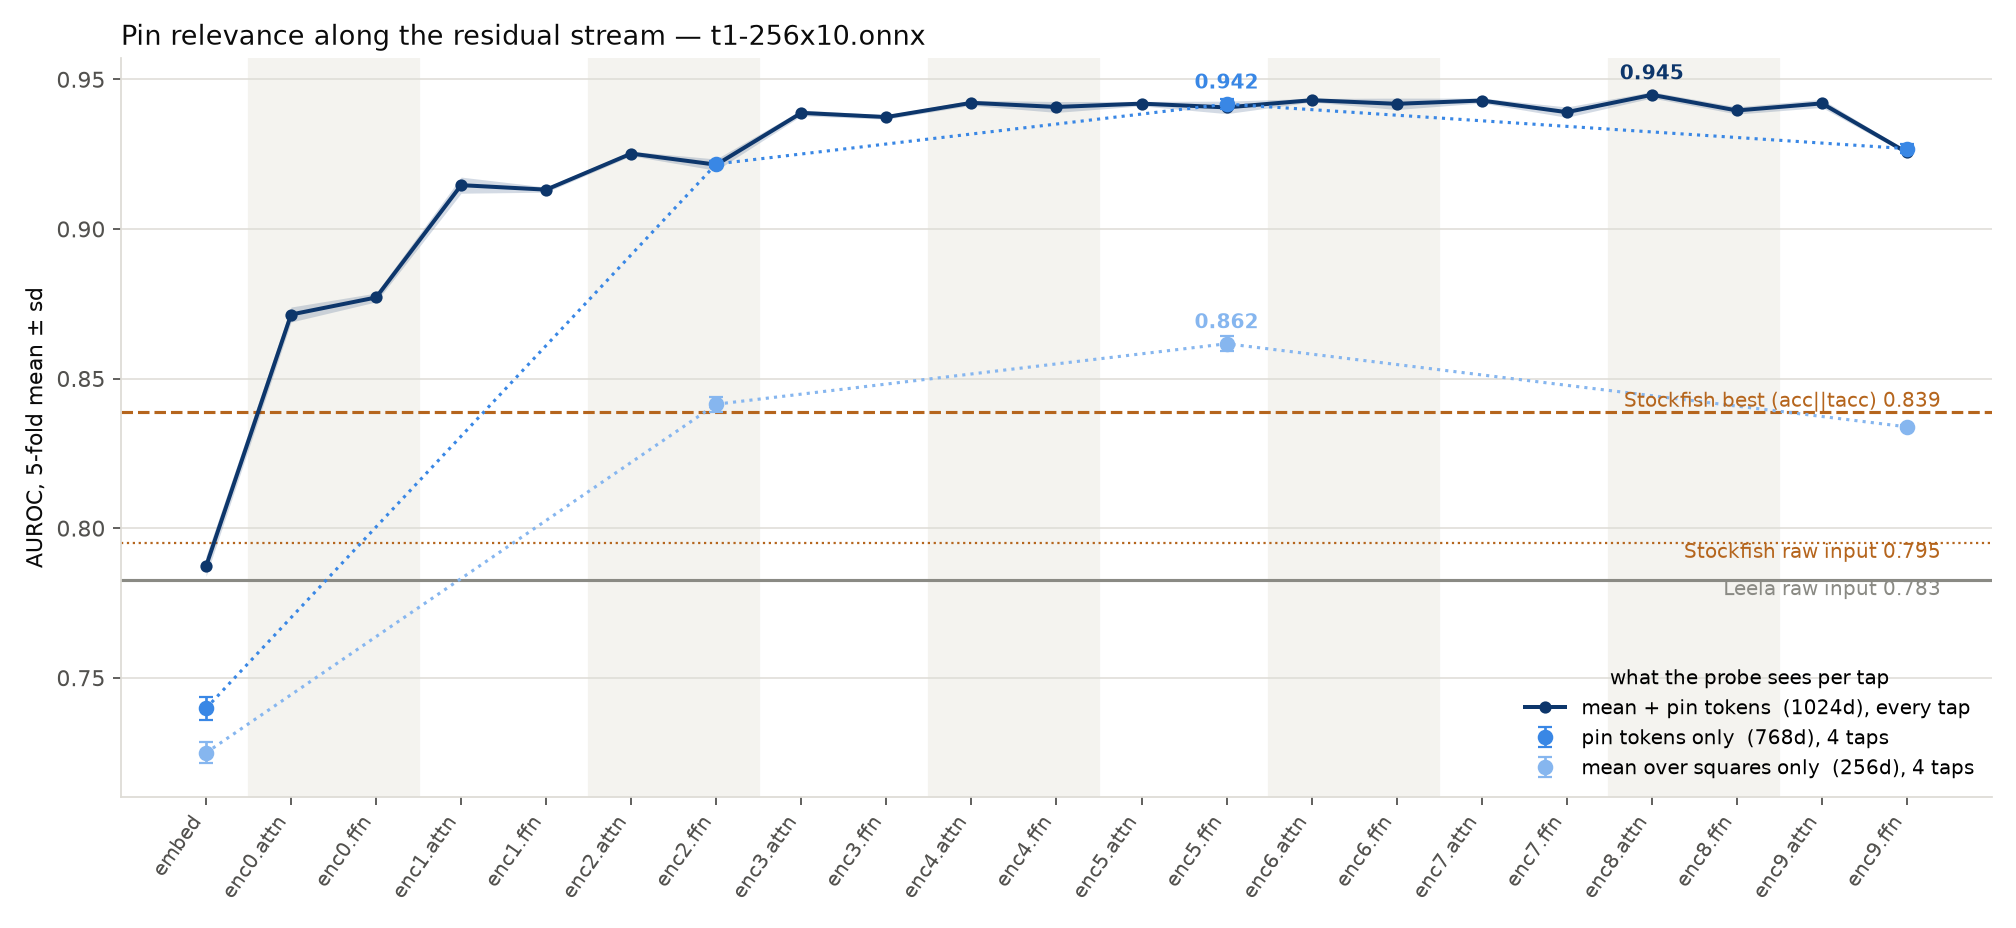

In [10]:
from IPython.display import Image, display
display(Image(filename=str(OUT_PNG)))

## 10 · Reading it

Same probe, same folds, same labels as the Stockfish sweep; a difference between
columns is a difference in the representation.

- **The embedding knows what the input knows.** `embed all` 0.787 vs the raw planes
  0.783 (Stockfish's raw input: 0.795). The gated linear embedding adds nothing yet.
- **Block 0 adds +0.09, block 1 another +0.04.** 0.877 after the first block, 0.913
  after the second, 0.938 after block 3. Pin relevance is assembled in the first four
  blocks, mostly by attention: within a block the `attn` tap is at or above the `ffn`
  tap from block 2 on.
- **Plateau 0.940–0.945 from block 4 to block 9's attention**, peak `enc8.attn` 0.945.
  The last FFN, the head's input, drops to 0.926: the network discards some of it on
  the way to policy and value, the same shape as Stockfish's cliff after `l1`, an
  order of magnitude smaller.
- **Every block from the first on beats Stockfish's best layer** (`acc||tacc` 0.839).
  The peak is +0.106 above it, and the mean-pooled residual alone (256 numbers, no
  square information) matches it at block 2 (0.841) and beats it at block 5 (0.862).
- **The pin's three squares carry it.** `pin` at `enc5.ffn` is 0.942 against `all`
  0.941; adding the mean of the other 61 squares changes nothing. At the embedding
  neither view alone reaches the input (0.740 / 0.725), so the tokens become
  informative through attention, not from the planes on those squares.

Caveats: the ceiling is still agreement with the Lichess `pin` tag, not ground truth.
The net is the smallest transformer in the contrib set (256 x 10); a BT4-size net was
not run. The probe sees 4 of 64 tokens per tap; the full residual was not stored.